In [1]:
import torchvision
import torch.nn as nn
import torch
import torch.nn.functional as F
from torchvision import transforms,models,datasets
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from torch import optim
device = 'cuda' if torch.cuda.is_available() else 'cpu'
import cv2, glob, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split, Subset
from pathlib import Path

In [2]:
%pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 43.9 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=5f2609d635f6389fd2dd7759e52e40eaae53b028967e54aafa1afc577ef8b7dd
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


# Data loading and pre-processing (same as for lab 2.1)

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Path to dataset files: /kaggle/input/plantvillage-dataset


In [4]:
root = Path(path)
data_root = root / "plantvillage dataset" / "color" # or "grayscale"

In [5]:
IMG_SIZE = 224 # image size expected for VGG / ResNet

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.02),
    transforms.ToTensor(), # converts HxWxC [0,255] -> CxHxW [0,1]
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(), # converts HxWxC [0,255] -> CxHxW [0,1]
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

In [6]:
full_ds = datasets.ImageFolder(data_root, transform=train_tfms)
all_classes = full_ds.classes
print("Total classes:", len(all_classes))
print("Example classes:", all_classes[:10])

N_CLASSES = 5
selected_classes = all_classes[:N_CLASSES]
selected_class_to_idx = {c: full_ds.class_to_idx[c] for c in selected_classes}
print("Selected:", selected_classes)

# wybieramy indeksy próbek należących do wybranych klas
sel_indices = [i for i, (_, y) in enumerate(full_ds.samples) if y in selected_class_to_idx.values()]
ds_sel = Subset(full_ds, sel_indices)

# split
n = len(ds_sel)
n_train = int(0.8 * n)
n_val = int(0.1 * n)
n_test = n - n_train - n_val

g = torch.Generator().manual_seed(42)
ds_train, ds_val, ds_test = random_split(ds_sel, [n_train, n_val, n_test], generator=g)

# val/test powinny mieć eval_tfms, więc podmieniamy transform w "bazowym" dataset
full_ds_eval = datasets.ImageFolder(data_root, transform=eval_tfms)
ds_sel_eval = Subset(full_ds_eval, sel_indices)
ds_train = Subset(ds_sel, ds_train.indices)     # train z augmentacją
ds_val = Subset(ds_sel_eval, ds_val.indices)    # val bez augmentacji
ds_test = Subset(ds_sel_eval, ds_test.indices)  # test bez augmentacji

len(ds_train), len(ds_val), len(ds_test)

Total classes: 38
Example classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']
Selected: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


(3738, 467, 468)

In [7]:
BATCH_SIZE = 128
num_dl_workers = 0

train_dl = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_dl_workers, pin_memory=True)
val_dl   = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_dl_workers, pin_memory=True)
test_dl  = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_dl_workers, pin_memory=True)

# Standard helper functions

In [8]:
def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()

In [9]:
@torch.no_grad()
def accuracy(x, y, model):
    model.eval()
    logits = model(x)
    is_correct = (logits.argmax(1) == y)  # select class with the highest score (probability)
    return is_correct.cpu().numpy().tolist()

# Transfer learning with VGG16

In [10]:
def get_vgg_model():
    model = models.vgg16(pretrained=True)
    for param in model.parameters():
        param.requires_grad = False
    model.avgpool = nn.AdaptiveAvgPool2d(output_size=(1, 1))
    model.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(512, 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, N_CLASSES) # multi-class classification
    )
    loss_fn = nn.CrossEntropyLoss() # multi-class classification
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    return model.to(device), loss_fn, optimizer

In [11]:
vgg_model, vgg_loss_fn, vgg_optimizer = get_vgg_model()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 224MB/s] 


In [12]:
EPOCHS = 5

### standard training loop

In [13]:
vgg_train_losses, vgg_train_accuracies = [], []
vgg_val_accuracies = []
for epoch in range(EPOCHS):
    print(f" epoch {epoch + 1}/{EPOCHS}")
    train_epoch_losses, train_epoch_accuracies = [], []
    val_epoch_accuracies = []

    for ix, batch in enumerate(iter(train_dl)):
        x, y = batch
        x, y = x.to(device), y.to(device)
        batch_loss = train_batch(x, y, vgg_model, vgg_optimizer, vgg_loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(train_dl)):
        x, y = batch
        x, y = x.to(device), y.to(device)
        is_correct = accuracy(x, y, vgg_model)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        x, y = x.to(device), y.to(device)
        val_is_correct = accuracy(x, y, vgg_model)
        val_epoch_accuracies.extend(val_is_correct)
    val_epoch_accuracy = np.mean(val_epoch_accuracies)

    vgg_train_losses.append(train_epoch_loss)
    vgg_train_accuracies.append(train_epoch_accuracy)
    vgg_val_accuracies.append(val_epoch_accuracy)

 epoch 1/5
 epoch 2/5
 epoch 3/5
 epoch 4/5
 epoch 5/5


### accuracy change during training

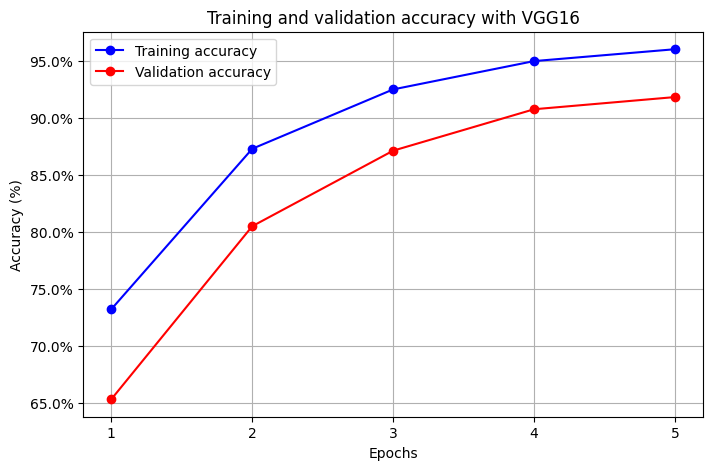

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

epochs = np.arange(len(vgg_train_accuracies)) + 1

plt.figure(figsize=(8,5))
plt.plot(epochs, vgg_train_accuracies, "bo-", label="Training accuracy")
plt.plot(epochs, vgg_val_accuracies, "ro-", label="Validation accuracy")

plt.title("Training and validation accuracy with VGG16")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.xticks(epochs)

# y-axis as percentages
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.legend()
plt.grid(True)
plt.show()

### Visualization of Activation Maps

In [33]:
from pytorch_grad_cam import GradCAM, HiResCAM, GradCAMPlusPlus, EigenCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [16]:
im, label = ds_test[0]
input_tensor = im.unsqueeze(0)  # add batch dim
input_tensor = input_tensor.to(device)

In [17]:
# denormalize for visualization
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

rgb_img = (im * std + mean).clamp(0,1)
rgb_img = rgb_img.permute(1,2,0).cpu().numpy()

In [18]:
for param in vgg_model.parameters():
    param.requires_grad = True

targets = [ClassifierOutputTarget(label)]

In [38]:
target_layers = [vgg_model.features[-1]]

In [39]:
with GradCAM(model=vgg_model, target_layers=target_layers) as cam:
    grayscale_cam = cam(input_tensor=input_tensor)
    grayscale_cam = grayscale_cam[0]

    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

In [40]:
# Testy pokazały, że grad-cam w pewnych przypadkach podświetla niestotne dla budowy modelu fragmenty obrazu - jej poprawiona wersja to algorytm HiResCAM
with HiResCAM(model=vgg_model, target_layers=target_layers) as cam:
    grayscale_cam = cam(input_tensor=input_tensor)
    grayscale_cam = grayscale_cam[0]

    cam_image_hr = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

In [41]:
# Like GradCAM but uses second order gradients
with GradCAMPlusPlus(model=vgg_model, target_layers=target_layers) as cam:
    grayscale_cam = cam(input_tensor=input_tensor)
    grayscale_cam = grayscale_cam[0]

    cam_image_pp = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# Takes the first principle component of the 2D Activations (no class discrimination, but seems to give great results)
with EigenCAM(model=vgg_model, target_layers=target_layers) as cam:
    grayscale_cam = cam(input_tensor=input_tensor)
    grayscale_cam = grayscale_cam[0]

    cam_image_eigen = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

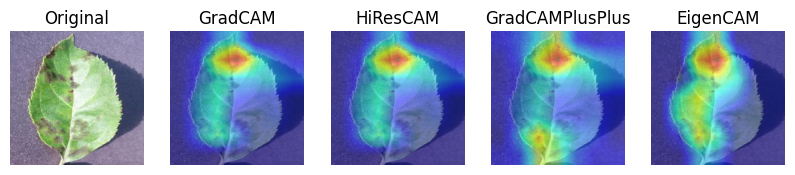

In [42]:
plt.figure(figsize=(10,4))

plt.subplot(1,5,1)
plt.title("Original")
plt.imshow(rgb_img)
plt.axis("off")

plt.subplot(1,5,2)
plt.title("GradCAM")
plt.imshow(cam_image)
plt.axis("off")

plt.subplot(1,5,3)
plt.title("HiResCAM")
plt.imshow(cam_image_hr)
plt.axis("off")

plt.subplot(1,5,4)
plt.title("GradCAMPlusPlus")
plt.imshow(cam_image_pp)
plt.axis("off")

plt.subplot(1,5,5)
plt.title("EigenCAM")
plt.imshow(cam_image_eigen)
plt.axis("off")

plt.show()

# Transfer learning with ResNet19

In [23]:
def get_resnet_model():
    model = models.resnet18(pretrained=True)
    for param in model.parameters():
        param.requires_grad = False
    model.avgpool = nn.AdaptiveAvgPool2d(output_size=(1,1))
    model.fc = nn.Sequential(nn.Flatten(),
        nn.Linear(512, 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, N_CLASSES) # multi-class classification
    )
    loss_fn = nn.CrossEntropyLoss() # multi-class classification
    optimizer = torch.optim.Adam(model.parameters(), lr= 1e-3)
    return model.to(device), loss_fn, optimizer

In [24]:
resnet_model, resnet_loss_fn, resnet_optimizer = get_resnet_model()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 166MB/s] 


In [25]:
resnet_train_losses, resnet_train_accuracies = [], []
resnet_val_accuracies = []
for epoch in range(EPOCHS):
    print(f" epoch {epoch + 1}/{EPOCHS}")
    train_epoch_losses, train_epoch_accuracies = [], []
    val_epoch_accuracies = []

    for ix, batch in enumerate(iter(train_dl)):
        x, y = batch
        x, y = x.to(device), y.to(device)
        batch_loss = train_batch(x, y, resnet_model, resnet_optimizer, resnet_loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(train_dl)):
        x, y = batch
        x, y = x.to(device), y.to(device)
        is_correct = accuracy(x, y, resnet_model)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        x, y = x.to(device), y.to(device)
        val_is_correct = accuracy(x, y, resnet_model)
        val_epoch_accuracies.extend(val_is_correct)
    val_epoch_accuracy = np.mean(val_epoch_accuracies)

    resnet_train_losses.append(train_epoch_loss)
    resnet_train_accuracies.append(train_epoch_accuracy)
    resnet_val_accuracies.append(val_epoch_accuracy)

 epoch 1/5
 epoch 2/5
 epoch 3/5
 epoch 4/5
 epoch 5/5


### accuracy change during training

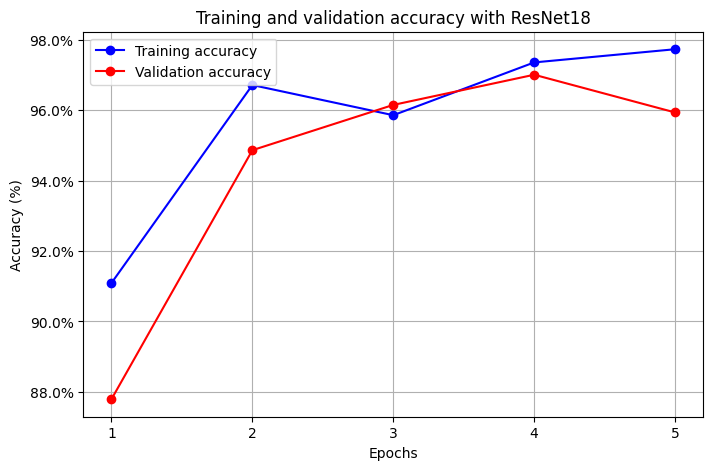

In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

epochs = np.arange(len(resnet_train_accuracies)) + 1

plt.figure(figsize=(8,5))
plt.plot(epochs, resnet_train_accuracies, "bo-", label="Training accuracy")
plt.plot(epochs, resnet_val_accuracies, "ro-", label="Validation accuracy")

plt.title("Training and validation accuracy with ResNet18")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.xticks(epochs)

# y-axis as percentages
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.legend()
plt.grid(True)
plt.show()

### Visualization of Activation Maps
using the same image as for VGG16

In [27]:
for param in resnet_model.parameters():
    param.requires_grad = True

targets = [ClassifierOutputTarget(label)]

In [28]:
target_layers = [resnet_model.layer4[-1]]

In [29]:
with GradCAM(model=resnet_model, target_layers=target_layers) as cam:
    grayscale_cam = cam(input_tensor=input_tensor)
    grayscale_cam = grayscale_cam[0]

    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

In [30]:
# Testy pokazały, że grad-cam w pewnych przypadkach podświetla niestotne dla budowy modelu fragmenty obrazu - jej poprawiona wersja to algorytm HiResCAM
with HiResCAM(model=resnet_model, target_layers=target_layers) as cam:
    grayscale_cam = cam(input_tensor=input_tensor)
    grayscale_cam = grayscale_cam[0]

    cam_image_hr = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

In [34]:
with GradCAMPlusPlus(model=resnet_model, target_layers=target_layers) as cam:
    grayscale_cam = cam(input_tensor=input_tensor)
    grayscale_cam = grayscale_cam[0]

    cam_image_pp = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

with EigenCAM(model=resnet_model, target_layers=target_layers) as cam:
    grayscale_cam = cam(input_tensor=input_tensor)
    grayscale_cam = grayscale_cam[0]

    cam_image_eigen = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

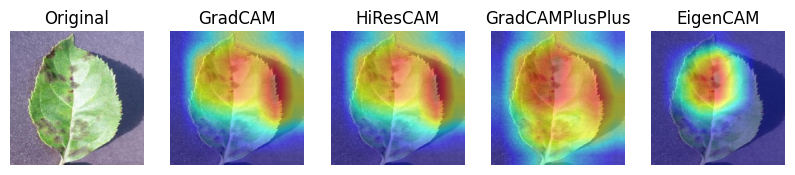

In [36]:
plt.figure(figsize=(10,4))

plt.subplot(1,5,1)
plt.title("Original")
plt.imshow(rgb_img)
plt.axis("off")

plt.subplot(1,5,2)
plt.title("GradCAM")
plt.imshow(cam_image)
plt.axis("off")

plt.subplot(1,5,3)
plt.title("HiResCAM")
plt.imshow(cam_image_hr)
plt.axis("off")

plt.subplot(1,5,4)
plt.title("GradCAMPlusPlus")
plt.imshow(cam_image_pp)
plt.axis("off")

plt.subplot(1,5,5)
plt.title("EigenCAM")
plt.imshow(cam_image_eigen)
plt.axis("off")

plt.show()